In [ ]:
# ============================================================
# Cats vs Dogs Image Classification Using CNN
# Authors: Staniella Francourt, Wendy Pointe, Michael Quatre
# Version 1.0

# Description:
# This program implements a Convolutional Neural Network (CNN)
# using TensorFlow/Keras to classify images as either cats or dogs.

# This project includes dataset loading, image preprocessing, 
# CNN Architecture design, model training, evaluation and 
# predication of new images.

In [10]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

# TensorFlow is the main deep-learning framework used
# to create and train the CNN.
import tensorflow as tf

# NumPy is used for numerical and array operations.
import numpy as np

# Matplotlib is used to display images and graphs.
import matplotlib.pyplot as plt

# Keras models and layers are used to construct the CNN.
from tensorflow.keras import models, layers

# Scikit-learn provides tools for splitting data
# and evaluating the model.
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


# ============================================================
# PROJECT PARAMETERS
# ============================================================

# Number of times the CNN will go through the training data.
EPOCHS = 15

# Number of images processed before the model updates
# its weights.
BATCH_SIZE = 32

# Random seed used to make the data split reproducible.
RANDOM_STATE = 123

# Seeding TensorFlow and NumPy as well as the data split makes
# weight initialisation and Dropout behaviour reproducible, so
# re-running the notebook produces consistent results.
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
# ============================================================
# 2. LOAD AND FILTER THE CIFAR-10 DATASET
# ============================================================

# CIFAR-10 contains 60,000 colour images belonging
# to 10 different classes.
cifar10 = tf.keras.datasets.cifar10


# Load the training and testing images and their labels.
(training_images, training_labels), (test_images, test_labels) = \
    cifar10.load_data()


# ------------------------------------------------------------
# CIFAR-10 CLASS LABELS
# ------------------------------------------------------------

# CIFAR-10 uses the following numerical labels:
#
# 0 = Airplane
# 1 = Automobile
# 2 = Bird
# 3 = Cat
# 4 = Deer
# 5 = Dog
# 6 = Frog
# 7 = Horse
# 8 = Ship
# 9 = Truck
#
# This project only requires cats and dogs.


# ------------------------------------------------------------
# FILTER TRAINING DATA
# ------------------------------------------------------------

# Select only images labelled as cats (3) or dogs (5).
train_filter = (
    (training_labels.flatten() == 3) |
    (training_labels.flatten() == 5)
)


# Apply the filter to the training images and labels.
training_images = training_images[train_filter]
training_labels = training_labels[train_filter]


# ------------------------------------------------------------
# FILTER TEST DATA
# ------------------------------------------------------------

# Select only cat and dog images from the test dataset.
test_filter = (
    (test_labels.flatten() == 3) |
    (test_labels.flatten() == 5)
)


# Apply the filter to the test images and labels.
test_images = test_images[test_filter]
test_labels = test_labels[test_filter]


# ------------------------------------------------------------
# CONVERT LABELS TO BINARY VALUES
# ------------------------------------------------------------

# Convert:
# Cat = 3 -> 0
# Dog = 5 -> 1

training_labels = (
    training_labels.flatten() == 5
).astype(int)

test_labels = (
    test_labels.flatten() == 5
).astype(int)


# Display the size of the filtered datasets.
print("Training images:", training_images.shape)
print("Training labels:", training_labels.shape)

print("Testing images:", test_images.shape)
print("Testing labels:", test_labels.shape)

print("Classes: Cat = 0, Dog = 1")

Training images: (10000, 32, 32, 3)
Training labels: (10000,)
Testing images: (2000, 32, 32, 3)
Testing labels: (2000,)
Classes: Cat = 0, Dog = 1


In [12]:
# ============================================================
# 3. CREATE TRAINING AND VALIDATION DATA
# ============================================================

# Split the filtered training dataset into:
# 80% training data
# 20% validation data.

# stratify=training_labels ensures that both the training and
# validation sets keep the same proportion of cat and dog images
# as the original dataset, preventing either split from becoming
# imbalanced.
training_images, validation_images, \
training_labels, validation_labels = train_test_split(
    training_images,
    training_labels,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=training_labels
)


# Display the number of images in each dataset.
print("Training images:", training_images.shape)
print("Validation images:", validation_images.shape)
print("Testing images:", test_images.shape)

Training images: (8000, 32, 32, 3)
Validation images: (2000, 32, 32, 3)
Testing images: (2000, 32, 32, 3)


In [13]:
# ============================================================
# 4. NORMALIZE THE IMAGE DATA
# ============================================================

# Pixel values originally range from 0 to 255.
# Dividing by 255 converts them to a range between 0 and 1.

training_images = training_images / 255.0

validation_images = validation_images / 255.0

test_images = test_images / 255.0


print("Image normalization completed.")
print("Pixel values are now between 0 and 1.")

Image normalization completed.
Pixel values are now between 0 and 1.


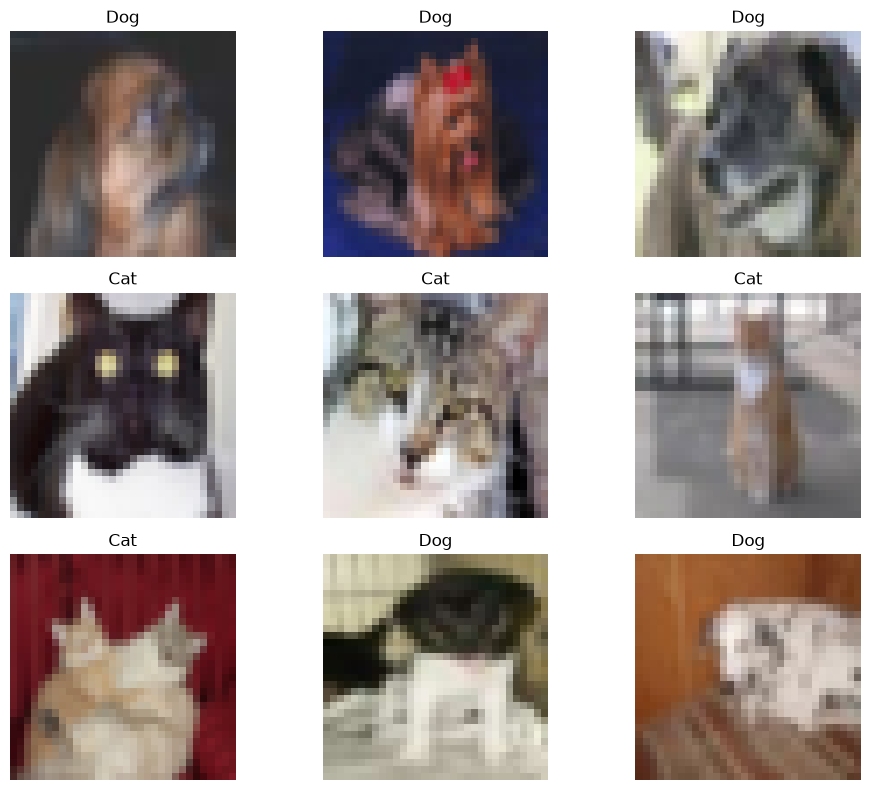

In [14]:
# ============================================================
# 5. DISPLAY SAMPLE CAT AND DOG IMAGES
# ============================================================

# Create a figure for displaying sample images.
plt.figure(figsize=(10, 8))


# Display the first nine training images.
for i in range(9):

    # Create a 3 x 3 grid.
    plt.subplot(3, 3, i + 1)

    # Display the image.
    plt.imshow(training_images[i])

    # Convert the numerical label into a class name.
    if training_labels[i] == 0:
        class_name = "Cat"
    else:
        class_name = "Dog"

    # Display the class name.
    plt.title(class_name)

    # Remove axis markings.
    plt.axis("off")


plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 6. CREATE THE CONVOLUTIONAL NEURAL NETWORK
# ============================================================

model = models.Sequential([

    # --------------------------------------------------------
    # INPUT
    # --------------------------------------------------------

    # CIFAR-10 images are 32 x 32 pixels with 3 colour channels.
    layers.Input(shape=(32, 32, 3)),


    # --------------------------------------------------------
    # FIRST CONVOLUTIONAL BLOCK
    # --------------------------------------------------------

    # 32 filters are used to learn basic visual features
    # such as edges, lines and simple patterns.
    # "same" padding preserves the spatial dimensions of
    # the feature maps during convolution.
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    # Batch normalization helps stabilise the activations
    # during training.
    layers.BatchNormalization(),

    # Reduce the spatial dimensions by a factor of two.
    layers.MaxPooling2D(
        (2, 2)
    ),


    # --------------------------------------------------------
    # SECOND CONVOLUTIONAL BLOCK
    # --------------------------------------------------------

    # 64 filters allow the network to learn more complex
    # visual features.
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    # Normalize the activations for more stable training.
    layers.BatchNormalization(),

    # Further reduce the spatial dimensions.
    layers.MaxPooling2D(
        (2, 2)
    ),


    # --------------------------------------------------------
    # THIRD CONVOLUTIONAL BLOCK
    # --------------------------------------------------------

    # 128 filters allow the CNN to learn higher-level
    # visual features.
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    # Normalize the activations.
    layers.BatchNormalization(),

    # Reduce the feature-map dimensions again.
    layers.MaxPooling2D(
        (2, 2)
    ),


    # --------------------------------------------------------
    # FLATTEN LAYER
    # --------------------------------------------------------

    # Convert the extracted feature maps into a
    # one-dimensional vector.
    layers.Flatten(),


    # --------------------------------------------------------
    # DENSE LAYER
    # --------------------------------------------------------

    # This fully connected layer combines the features
    # extracted by the convolutional layers.
    layers.Dense(
        128,
        activation="relu"
    ),


    # --------------------------------------------------------
    # DROPOUT LAYER
    # --------------------------------------------------------

    # Randomly disables 50% of neurons during training.
    # This helps reduce the risk of overfitting.
    layers.Dropout(
        0.5
    ),


    # --------------------------------------------------------
    # OUTPUT LAYER
    # --------------------------------------------------------

    # One output neuron is used because this is a
    # binary classification problem.
    #
    # Sigmoid produces a value between 0 and 1,
    # representing the predicted probability of the Dog class.
    layers.Dense(
        1,
        activation="sigmoid"
    )
])


print("CNN model created successfully.")

CNN model created successfully.


In [16]:
# ============================================================
# 7. DISPLAY AND COMPILE THE CNN
# ============================================================

# Display the structure of the CNN.
model.summary()


# ------------------------------------------------------------
# COMPILE THE MODEL
# ------------------------------------------------------------

# Adam is used to optimize the model weights.
#
# Binary cross-entropy is appropriate because this is
# a binary classification problem.
#
# Accuracy measures the proportion of correctly classified
# images.

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


print("Model compiled successfully.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,545 (1.36 MB)

 Trainable params: 356,097 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Model compiled successfully.


In [17]:
# ============================================================
# 8. TRAIN THE CNN MODEL
# ============================================================

# Early stopping monitors validation loss.
#
# If validation loss does not improve for three consecutive
# epochs, training is stopped to reduce unnecessary training
# and help limit overfitting.
#
# The weights from the epoch with the best validation loss
# are restored.

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


# Train the CNN using the training dataset.
#
# Validation data is supplied so that the model's performance
# on unseen validation images can be monitored during training.

history = model.fit(
    training_images,
    training_labels,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(
        validation_images,
        validation_labels
    ),
    callbacks=[early_stop]
)


print("Model training completed.")
print("Epochs completed:", len(history.history["loss"]))

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5972 - loss: 0.7239 - val_accuracy: 0.5640 - val_loss: 0.8617
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6514 - loss: 0.6238 - val_accuracy: 0.6460 - val_loss: 0.6423
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6933 - loss: 0.5829 - val_accuracy: 0.6390 - val_loss: 0.6450
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7241 - loss: 0.5323 - val_accuracy: 0.6855 - val_loss: 0.5697
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7485 - loss: 0.4982 - val_accuracy: 0.7085 - val_loss: 0.5540
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7832 - loss: 0.4477 - val_accuracy: 0.7010 - val_loss: 0.5626
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8031 - loss: 0.4145 - val_accuracy: 0.7095 - val_loss: 0.5818
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8344 - loss: 0.3601 - val_accu

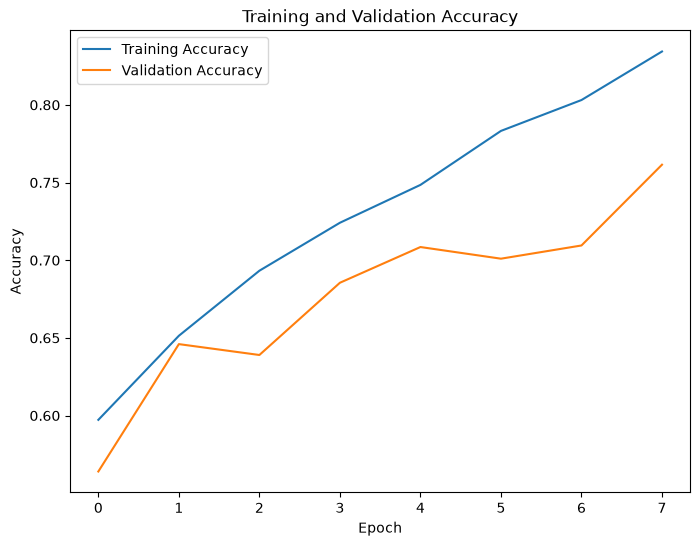

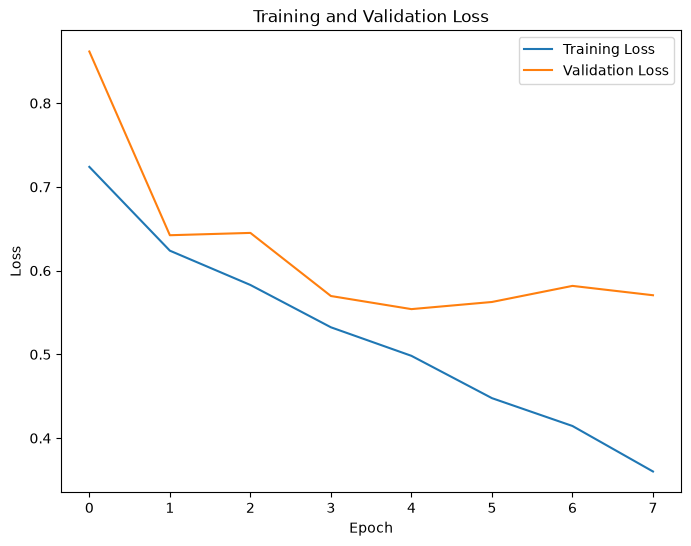

In [18]:
# ============================================================
# 9. VISUALIZE TRAINING PERFORMANCE
# ============================================================

# Plotting training and validation accuracy/loss together makes
# it possible to visually check for overfitting: if training
# performance keeps improving while validation performance
# plateaus or worsens, the model is starting to memorise the
# training data rather than generalising to new images.

# ------------------------------------------------------------
# TRAINING AND VALIDATION ACCURACY
# ------------------------------------------------------------


plt.figure(figsize=(8, 6))


# Accuracy on the training data the model was trained on.
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

# Accuracy on the validation data, which the model's weights
# were never directly updated on.
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training and Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.show()


# ------------------------------------------------------------
# TRAINING AND VALIDATION LOSS
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))


# Plot training loss.
plt.plot(
    history.history["loss"],
    label="Training Loss"
)

# Plot validation loss.
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.show()

In [19]:
# ============================================================
# 10. EVALUATE THE TRAINED CNN
# ============================================================

# Evaluate the trained model using the separate test dataset.


test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=2
)


print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

63/63 - 0s - 5ms/step - accuracy: 0.7090 - loss: 0.5494
Test Loss: 0.5494
Test Accuracy: 0.7090


In [20]:
# ============================================================
# 11. GENERATE CLASSIFICATION REPORT
# ============================================================

# Generate probability predictions for the test images.
probabilities = model.predict(
    test_images,
    batch_size=BATCH_SIZE,
    verbose=1
)


# Convert probabilities into binary predictions.
#
# Probability >= 0.5 -> Dog (1)
# Probability < 0.5  -> Cat (0)

predicted_labels = (
    probabilities >= 0.5
).astype(int).flatten()


# Generate and display the classification report.
print("Classification Report:")

print(
    classification_report(
        test_labels,
        predicted_labels,
        target_names=["Cat", "Dog"]
    )
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Classification Report:
              precision    recall  f1-score   support

         Cat       0.80      0.56      0.66      1000
         Dog       0.66      0.85      0.75      1000

    accuracy                           0.71      2000
   macro avg       0.73      0.71      0.70      2000
weighted avg       0.73      0.71      0.70      2000



Confusion Matrix:
[[563 437]
 [145 855]]


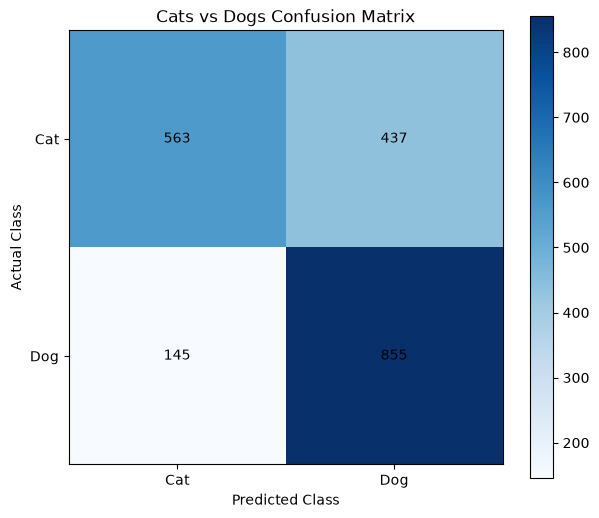

In [22]:
# ============================================================
# 12. CREATE THE CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix.
cm = confusion_matrix(
    test_labels,
    predicted_labels
)


# Display the numerical confusion matrix.
print("Confusion Matrix:")
print(cm)


# ------------------------------------------------------------
# DISPLAY THE CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

# The Blues colormap gives a clear visual distinction between
# correctly and incorrectly classified cells.
plt.imshow(cm, cmap="Blues")

plt.title(
    "Cats vs Dogs Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    [0, 1],
    ["Cat", "Dog"]
)

plt.yticks(
    [0, 1],
    ["Cat", "Dog"]
)


# Display the values inside the matrix.
for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.colorbar()

plt.show()

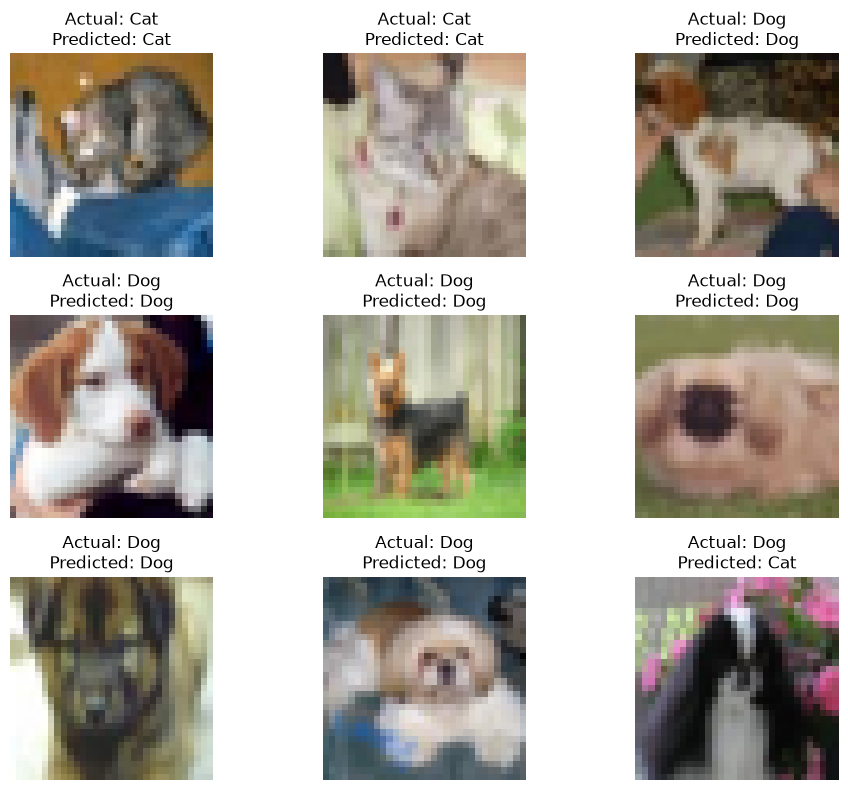

Model saved as cifar10_cat_dog_cnn.keras


In [39]:
# ============================================================
# 13. DISPLAY EXAMPLE PREDICTIONS AND SAVE THE MODEL
# ============================================================

# ------------------------------------------------------------
# DISPLAY SAMPLE TEST PREDICTIONS
# ------------------------------------------------------------

# Displays a grid of test images with both their actual and
# predicted labels, to visually check the model's performance
# across several examples at once, rather than just one.
plt.figure(figsize=(10, 8))


for i in range(9):

    plt.subplot(3, 3, i + 1)


    # Display the test image.
    plt.imshow(test_images[i])


    # Determine the actual class.
    if test_labels[i] == 0:
        actual_class = "Cat"
    else:
        actual_class = "Dog"


    # Determine the predicted class.
    if predicted_labels[i] == 0:
        predicted_class = "Cat"
    else:
        predicted_class = "Dog"


    # Display actual and predicted classes.
    plt.title(
        "Actual: " + actual_class +
        "\nPredicted: " + predicted_class
    )

    plt.axis("off")


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# SAVE THE TRAINED MODEL
# ------------------------------------------------------------

# Save the trained CNN so that it can be reused later
# without having to train it again.

model.save(
    "cifar10_cat_dog_cnn.keras"
)


print(
    "Model saved as cifar10_cat_dog_cnn.keras"
)

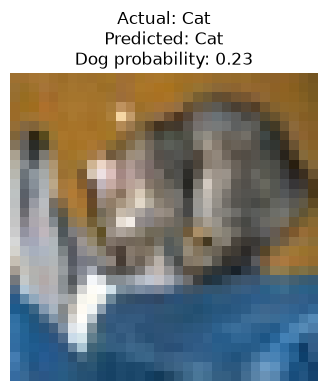

Actual class: Cat
Predicted class: Cat
Predicted probability (Dog): 0.2295


In [25]:
# ============================================================
# 14. DEMONSTRATION: CLASSIFY A SINGLE IMAGE
# ============================================================

# Select one test image to demonstrate the prediction process.
# Change this index to try a different image.

demo_index = 0
demo_image = test_images[demo_index]

# The model expects a batch of images, so add a batch dimension.
demo_input = np.expand_dims(
    demo_image,
    axis=0
)

# Obtain the predicted probability for the Dog class.
demo_probability = model.predict(
    demo_input,
    verbose=0
)[0][0]


# Convert the probability into a class label using
# the same 0.5 threshold used throughout the notebook.
demo_label = (
    "Dog"
    if demo_probability >= 0.5
    else "Cat"
)

# Determine the actual class for comparison.
demo_actual_label = "Dog" if test_labels[demo_index] == 1 else "Cat"

# Display the image together with the prediction
# and predicted Dog probability.
plt.figure(figsize=(4, 4))

plt.imshow(demo_image)

plt.title(
    f"Actual: {demo_actual_label}\n" 
    f"Predicted: {demo_label}\n"
    f"Dog probability: {demo_probability:.2f}"
)

plt.axis("off")

plt.show()


# Display the final prediction in text.
print(f"Actual class: {demo_actual_label}")
print(f"Predicted class: {demo_label}")
print(f"Predicted probability (Dog): {demo_probability:.4f}")